# References
- Perform Sentiment Analysis on Twitter data by combining Text Mining and NLP techniques, NLTK and Scikit-Learn
- by Benjamin Termonia
- provided by Udemy Business

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [3]:
df.sample(10)

,textID,tweet_text,sentiment
16912,1753256158,@XKirstyxo Really? A good distraction now. I'l...,positive
16380,1753028776,add me up: http://profiles.friendster.com/amer...,positive
4378,1962438708,@Twisted_Jo my mask is non-existent at the mo ...,positive
13463,1751036038,im joining twitter lol,positive
4754,1962781825,"ahhhh, very sad",negative
12095,1695219958,@crafty Hope it went well! Was rooting for you...,positive
2206,1960464262,@DGNY I'm ready homie..actually ima be working,positive
13409,1750999901,@kyladreams aw you're the shit thanks so much...,positive
52,1956990288,@mrgenius23 You win ... SIGH Rakeem,positive
2490,1960673237,Hey #rda2009cla presentation was too large to ...,negative


## Visualise data

In [4]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

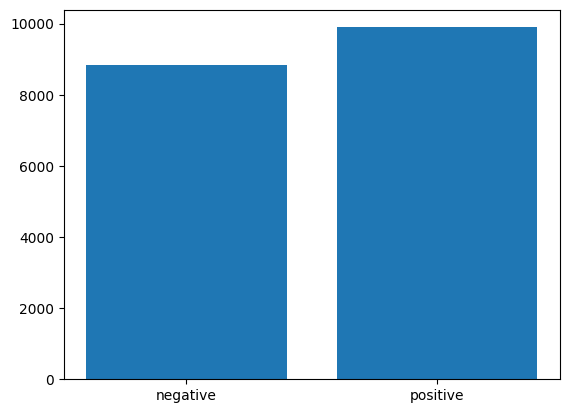

In [5]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

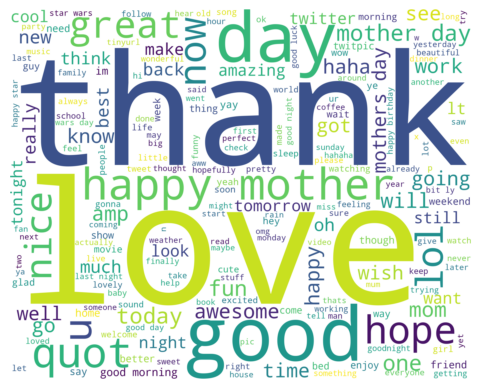

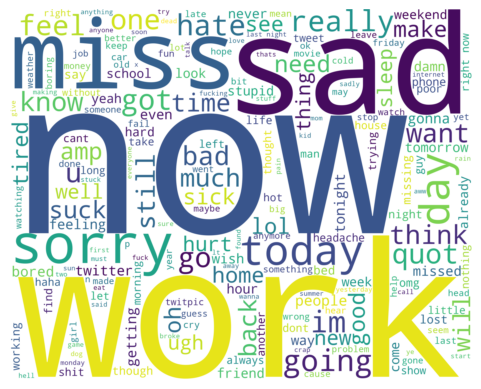

In [6]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [7]:
import re

In [8]:
# example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"

In [9]:
# Remove emojis
import emoji

In [10]:

def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

#print(convert_emoji_to_text(example))


In [11]:
# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text
#print (remove_links(example))

In [12]:
# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text

#print (remove_hashtags(example))

In [13]:
# General cleaning / text normalization

In [14]:
# Making string all lowercase
def lower_case_string(text):
    return text.lower()

#print (lower_case_string(example))

In [15]:
# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

#print (remove_letter_repetitions(example))

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

#print (remove_punctuation_repetitions(example))

In [16]:
# Working with contractions
# Using a contraction dictionary we can replace contractions with their full form
import contractions

In [17]:
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

#print(replace_contractions(example))

# Tokenization
- stop words
- punctionation
- numbers

In [18]:
# Using nltk library
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
def tokenize(text):
    tokens = word_tokenize(text)
    return tokens

#print(tokenize(example))

In [20]:
# Using a more complex and complete tokenizer
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
print(stop_words)

{'from', 'this', 'some', 'off', 'but', 'myself', "won't", "it's", 'hasn', 'isn', 'yourselves', 'into', 'll', 'we', 'having', 'by', 'it', 'if', 'through', "mightn't", 'they', 'further', 'at', 'that', 'before', 'can', 'too', "mustn't", 'then', 'has', 'doing', 'where', 'himself', "didn't", 'very', 'his', 'aren', 'down', "you've", "she's", 'ma', 'me', "hasn't", 'hers', 'while', 'each', 'both', 'whom', 'once', "shan't", 'my', 'any', 'did', 'just', 'o', 'needn', 'yourself', 't', 'ain', 'ourselves', 'their', 'shouldn', 'wouldn', 'were', 'was', 'no', 'than', 'itself', 'why', "don't", 'after', 'only', 'he', 'couldn', 'does', 's', 'its', 'him', 'because', "shouldn't", 'which', "that'll", 'you', 'will', "aren't", 'who', 'and', 'herself', 'd', 'weren', 'been', 'i', 'when', 'have', 'm', 'between', 'ours', 'being', 'now', 'shan', "you're", 'she', 'about', "weren't", 'am', 'doesn', 'against', 'over', 'under', 'didn', 'for', 'mustn', 'all', 'until', 'again', "couldn't", "you'd", 'or', 'out', 'same', '

In [22]:

# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    token_list = word_tokenize(text)

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in string.punctuation] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

#print(custom_tokenization(example, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False))

## Stemming

In [23]:
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer
#NOTE: can look at more stemming algos

In [24]:
porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
snowball_stemmer = SnowballStemmer('english')


In [25]:
# Function to stem tokens given a stemming algorithm
def stemming_tokens(tokens, stemmer):
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

In [26]:
#print(stemming_tokens(tokenize(example), snowball_stemmer))

# Preprocessing text

In [27]:
# Processing the string/text

def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    #p_txt = tokenize(p_txt)
    p_txt = custom_tokenization(p_txt)

    # Stemming the tokens
    p_txt = stemming_tokens(p_txt, snowball_stemmer)
    return p_txt

example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"
print(process_text(example))

['tom', 'love', 'food', 'spot', 'websit', 'info', 'sure', 'go', 'food', 'greatfood', 'bestfood']


# Text Vectorization

In [28]:
df["tokens"] = df["tweet_text"].apply(process_text)
df["tweet_sentiment"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

df.head(10)

,textID,tweet_text,sentiment,tokens,tweet_sentiment
0,1956967666,Layin n bed with a headache ughhhh...waitin o...,negative,"[layin, n, bed, headach, call]",0
1,1956967696,Funeral ceremony...gloomy friday...,negative,"[funer, friday]",0
2,1956967789,wants to hang out with friends SOON!,positive,"[want, hang, friend, soon]",1
3,1956968477,Re-pinging @ghostridah14: why didn't you go to...,negative,"[not, go, prom, bf, not, like, friend]",0
4,1956968636,Hmmm. http://www.djhero.com/ is down,negative,[hmm],0
5,1956969035,@charviray Charlene my love. I miss you,negative,"[charviray, charlen, love, miss]",0
6,1956969172,@kelcouch I'm sorry at least it's Friday?,negative,"[kelcouch, sorri, least, friday]",0
7,1956969531,Choked on her retainers,negative,"[choke, retain]",0
8,1956970047,Ugh! I have to beat this stupid song to get to...,negative,"[ugh, beat, stupid, song, get, next, rude]",0
9,1956970424,@BrodyJenner if u watch the hills in london u ...,negative,"[brodyjenn, watch, hill, london, realis, tourt...",0


In [29]:
x  = df["tokens"].tolist()
y = df["tweet_sentiment"].tolist()

## Bag of words

In [30]:
corpus = [["love", "nlp"],
          ["miss", "you"],
          ["hate", "hate", "hate", "love"],
          ["happy", "love", "hate",],
          ["i", "lost", "my", "computer"],
          ["i", "am", "so", "sad"]]

In [31]:
from sklearn.feature_extraction.text import CountVectorizer # Bag of words

def fit_cv(tweet_corpus):
    cv_vect = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x) # Using custom tokenizer and preprocessor

    cv_vect.fit(tweet_corpus)

    return cv_vect

cv_vect = fit_cv(corpus)

ft = cv_vect.get_feature_names_out()

print(ft)

['am' 'computer' 'happy' 'hate' 'i' 'lost' 'love' 'miss' 'my' 'nlp' 'sad'
 'so' 'you']


/opt/homebrew/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [32]:
cv_mtx = cv_vect.transform(corpus)

In [33]:
cv_mtx.toarray()

array([[0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0]])

## TD-IDF

- term frequency

In [34]:
corpus = [["love", "nlp"],
          ["miss", "you"],
          ["hate", "hate", "hate", "love"],
          ["happy", "love", "hate",],
          ["i", "lost", "my", "computer"],
          ["i", "am", "so", "sad"]]

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
def fit_tfidf(tween_corpus):
    tf_vect = TfidfVectorizer(preprocessor=lambda x: x, tokenizer=lambda x: x) # Using custom tokenizer and preprocessor

    tf_vect.fit(tween_corpus)
    return tf_vect

In [37]:
tf_vect = fit_tfidf(corpus)
tf_mtx = tf_vect.transform(corpus)

tf_mtx.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.56921261, 0.        , 0.        , 0.82219037,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.70710678, 0.        , 0.        ,
        0.        , 0.        , 0.70710678],
       [0.        , 0.        , 0.        , 0.96260755, 0.        ,
        0.        , 0.27089981, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.68172171, 0.55902156, 0.        ,
        0.        , 0.47196441, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.52182349, 0.        , 0.        , 0.42790272,
        0.52182349, 0.        , 0.        , 0.52182349, 0.        ,
        0.        , 0.        , 0.        ],
       [0.52182349, 0.        , 0.        , 0.        , 0.42790272,
        0.        , 0.     

# Train/Test Split

In [38]:
from sklearn.model_selection import train_test_split
import random

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, train_size=0.8)

# Showing the sentiment of the training data

# id = random.randint(0, len(x_train))

# print(x_train[id])
# print(y_train[id])

## Logistic Regression model
- Note: we only use train data as we do not want data leakage, we want the train and test data to be completely separate

In [39]:
## Using a model

from sklearn.linear_model import LogisticRegression

def fit_lr(x_train, y_train): # Fitting a logistic regression model
    lr = LogisticRegression()
    lr.fit(x_train, y_train)
    return lr

### Using Bag of words (Count vector)

In [40]:
cv = fit_cv(x_train) # only fit on the training data
x_train_cv = cv.transform(x_train) # transform the training data
x_test_cv = cv.transform(x_test) # transform the testing data


model_lr_cv = fit_lr(x_train_cv, y_train) # fit the model on the training data

### Using TF-IDF

In [41]:
tf = fit_tfidf(x_train) # only fit on the training data
x_train_tf = tf.transform(x_train) # transform the training data
x_test_tf = tf.transform(x_test) # transform the testing data

model_lr_tf = fit_lr(x_train_tf, y_train) # fit the model on the training data

/opt/homebrew/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


# Performance Metrics of the Models

In [44]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Using Bag of words

Accuracy of the model using CountVectorizer (Bag of Words):  0.8841430859583556


<Axes: >

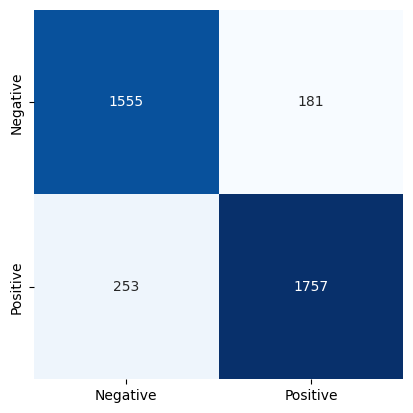

In [50]:
y_predict_lr_cv = model_lr_cv.predict(x_test_cv)

print("Accuracy of the model using CountVectorizer (Bag of Words): ", accuracy_score(y_test, y_predict_lr_cv))

conf_matrix = confusion_matrix(y_test, y_predict_lr_cv)

sns.heatmap(conf_matrix, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

## Using TF-IDF

Accuracy of the model using CountVectorizer (Bag of Words):  0.8833422317138281


<Axes: >

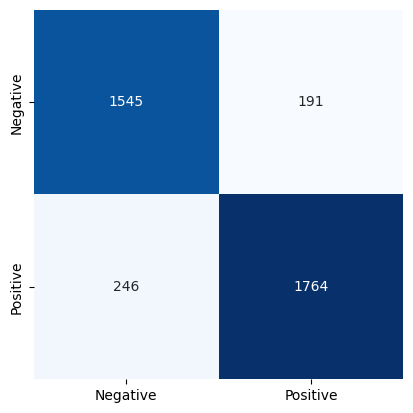

In [51]:
y_predict_lr_tf = model_lr_tf.predict(x_test_tf)

print("Accuracy of the model using CountVectorizer (Bag of Words): ", accuracy_score(y_test, y_predict_lr_tf))

conf_matrix = confusion_matrix(y_test, y_predict_lr_tf)

sns.heatmap(conf_matrix, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

# Setting up a mini-pipeline

In [53]:
# Final pipeline for prediciton of sentiment of a text
def predict_sentiment_text(text):
    processed_text = process_text(text) # Process the initial text
    tf_text = tf.transform([processed_text]) # Transform the processed text using a model (TF-IDF in this case)
    prediction = model_lr_tf.predict(tf_text) # Predict the sentiment of the text using the model

    if prediction == 1:
        return "The prediction of the text is positive. 😊"
    else:
        return "The prediction of the text is negative. 😞"

In [57]:
# Final example testing the pipeline
example = "I love this product, it's amazing! 😊"

print(predict_sentiment_text(example))

The prediction of the text is positive. 😊
